In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.float_format', lambda x: '{:.3f}'.format(x))

In [75]:
df = pd.read_csv("ForeignGifts_edu.csv")

Let's filter only the rows that pertain to UVA.

In [76]:
df_uva = df[df["Institution Name"] == "University of Virginia"]
df_uva.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
26235,26236,374500,University of Virginia,Charlottesville,VA,41822,3565,Monetary Gift,ENGLAND,West Yorkshire Police
26236,26237,374500,University of Virginia,Charlottesville,VA,41870,12265,Contract,ISRAEL,CureTech Ltd
26237,26238,374500,University of Virginia,Charlottesville,VA,41873,8187,Monetary Gift,ISRAEL,Branco Weiss Institute
26238,26239,374500,University of Virginia,Charlottesville,VA,41887,6437,Contract,ISRAEL,NovoCure Ltd
26239,26240,374500,University of Virginia,Charlottesville,VA,41904,216943,Contract,ISRAEL,InSightec-Image Guide Treatment Ltd


Now, we can visualize who are the top giftors by name for UVA

In [77]:
df_uva.groupby('Giftor Name')['Foreign Gift Amount'].sum().sort_values(ascending=False)

Giftor Name
AstraZeneca                            3208048
Intrnl Centre Diarrheal Disease        1382896
Haydom Lutheran Hospital d/b/a Hayd    1100553
Haydom Luther Hospital                 1035339
Harvest Group Holding                  1000000
Lawrence D/ Karin S Howell             1000000
Lawrence D & Karin S Howell            1000000
Danisco Sweeteners Oy                   990331
Intnl Centre for Diarrhoeal Disease     919857
International Centre for Diarrhoeal     919518
Hemera Foundation                       900000
Rainbow Foundation                      805000
Charities Aid Foundation                727928
Intl. Cntr for Diarrihoeal Disease      696317
AutoLiv Development AB                  685217
Haydom Lutheran Hospital                640555
Hyundai Motor Company                   568092
Harvest Group Holding (PTC Limited)     500000
Kirkhouse Trust                         366460
Charles Aid Foundation                  321029
Intl Ctr for Diarrhoeal Disease         310001
P

And by Country,

In [78]:
df_uva.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(20)

Country of Giftor
BANGLADESH         4228589
SWEDEN             4007552
TANZANIA           2776447
SWITZERLAND        2000000
ENGLAND            1950666
GUERNSEY           1500000
FINLAND            1008384
BERMUDA             900000
KOREA               862787
SINGAPORE           805000
THE NETHERLANDS     725670
ISRAEL              623655
RWANDA              284135
JAPAN               265970
FRANCE              250383
Name: Foreign Gift Amount, dtype: int64

We can note that amongst the top giftors for UVA, if not the majority of them, the giftors are mainly from hospitals, centers for disease, aid foundations, and pharmaceutical companies. Essentially, a large proportion of UVA's foreign money is concentrated in the healthcare industry. While we cannot directly conclude that this is exactly what that foreign money is being used for just from the data, we can make an educated guess that a large proportion of these foreign gifts could be focused on money for healthcare research/facilities.

This tells us that we may need to focus our strategy on investing in research in other schools/fields within UVA and develop relations with donors in other industry segments of the market.

Before we analyze UVA and its position in the overall market, I wanted to briefly assess its risk profile in terms of its current distribution of gifts. Does it receive a larger proportion of its gifts from only a few large donors or is it more diversified? I also wanted to analyze what type of gifts it receives a majority of to see if we need to diversify away from just one gift type when looking for new sources of foreign money.

In [79]:
#Proportion of each giftor's total gift amount
(df_uva.groupby('Giftor Name')['Foreign Gift Amount'].sum()
 /df_uva['Foreign Gift Amount'].sum()).sort_values(ascending=False)

Giftor Name
AstraZeneca                           0.145
Intrnl Centre Diarrheal Disease       0.062
Haydom Lutheran Hospital d/b/a Hayd   0.050
Haydom Luther Hospital                0.047
Harvest Group Holding                 0.045
Lawrence D/ Karin S Howell            0.045
Lawrence D & Karin S Howell           0.045
Danisco Sweeteners Oy                 0.045
Intnl Centre for Diarrhoeal Disease   0.041
International Centre for Diarrhoeal   0.041
Hemera Foundation                     0.041
Rainbow Foundation                    0.036
Charities Aid Foundation              0.033
Intl. Cntr for Diarrihoeal Disease    0.031
AutoLiv Development AB                0.031
Haydom Lutheran Hospital              0.029
Hyundai Motor Company                 0.026
Harvest Group Holding (PTC Limited)   0.023
Kirkhouse Trust                       0.017
Charles Aid Foundation                0.014
Intl Ctr for Diarrhoeal Disease       0.014
Pantarhei Oncology BV                 0.013
InSightec-Image Guid

By Country:

In [80]:
(df_uva.groupby('Country of Giftor')['Foreign Gift Amount'].sum()
 /df_uva['Foreign Gift Amount'].sum()).sort_values(ascending=False)

Country of Giftor
BANGLADESH        0.191
SWEDEN            0.181
TANZANIA          0.125
SWITZERLAND       0.090
ENGLAND           0.088
GUERNSEY          0.068
FINLAND           0.045
BERMUDA           0.041
KOREA             0.039
SINGAPORE         0.036
THE NETHERLANDS   0.033
ISRAEL            0.028
RWANDA            0.013
JAPAN             0.012
FRANCE            0.011
Name: Foreign Gift Amount, dtype: float64

While at first glance, our foreign gift sources seem pretty spread out, it should be noted that almost 50% of our gift amounts come from just 3 countries: Bangladesh, Sweden and Tanzania and our largest donor AstraZeneca makes up about 14.5% of our total foreign gift amount on its own. Any sudden loss of gift amounts from these sources could have a significant impact on our spending. 

Let us also look at how many gifts by count these giftors contribute.

In [81]:
df_uva.groupby('Country of Giftor')['Foreign Gift Amount'].count().sort_values(ascending=False)

Country of Giftor
ENGLAND            31
ISRAEL             12
BANGLADESH         10
SWEDEN             10
FINLAND             7
KOREA               6
FRANCE              5
THE NETHERLANDS     4
GUERNSEY            3
TANZANIA            3
SINGAPORE           2
SWITZERLAND         2
BERMUDA             1
RWANDA              1
JAPAN               1
Name: Foreign Gift Amount, dtype: int64

In [82]:
df_uva.groupby(['Country of Giftor', 'Giftor Name'])['Foreign Gift Amount'].count().sort_values(ascending=False)

Country of Giftor  Giftor Name                        
ENGLAND            Kirkhouse Trust                        9
SWEDEN             AutoLiv Development AB                 5
FINLAND            Danisco Sweeteners Oy                  4
ENGLAND            University of Newcastle                4
FINLAND            FKD Therapies Oy                       3
ENGLAND            Charities Aid Foundation               3
                   GW Research Ltd                        3
BANGLADESH         Intl. Cntr for Diarrihoeal Disease     3
                   Intrnl Centre Diarrheal Disease        3
ENGLAND            London School of Economics             3
ISRAEL             InSightec-Image Guide Treatment Ltd    3
SWEDEN             AstraZeneca                            2
FRANCE             Genfit                                 2
THE NETHERLANDS    Pantarhei Oncology BV                  2
GUERNSEY           Harvest Group Holding                  2
KOREA              Hyundai Motor Company     

From cross referencing gift amounts and gift counts between Country and Giftor, we actually notice even more risk associated with the gifts. Bangladesh's 19.1% contribution may have given 10 gifts but all of the gifts are from the same organization, "International Center for Diarrhoeal Disease". It just showed up as under separate donors due to variations in spelling/abbreviations.

Sweden covers 18% of our total gift amount but AstraZeneca accounts for 14.5% of that over just 2 gifts.

Tanzania as well accounts for 12.5% all from Haydom Luther Hospital over only 3 gifts, once again encoded as separate donors due to different spellings/abbreviatons.

This tells us that almost 48-50% of our total gift amount is sourced from only 3 donors. This marks our gift profile as high risk. We can tailor our strategy to uphold relationships with these donors to not suddenly lose out on any significant portion of our donations and it also lets us know we should try to diversify our sources of gifts to avoid any instability.

Finally, looking at gift type proportion:

In [83]:
(df_uva.groupby('Gift Type')['Foreign Gift Amount'].sum()
 /df_uva['Foreign Gift Amount'].sum())

Gift Type
Contract        0.667
Monetary Gift   0.333
Name: Foreign Gift Amount, dtype: float64

This is a healthy split of gift types as the type we would have wanted to avoid too much of is Real Estate due to the lack of liquidity and inaccuracy with valuations of these types of gifts.

## Comparison to Overall Market

Now let's look at the top countries of donors in the overall market as we did in the initial_analysis and compare it to the countries gifting to UVA

In [84]:
df.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(20)

Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
KUWAIT                   234106321
DENMARK                  173956102
THE NETHERLANDS          166062836
BRAZIL                   158757039
SWEDEN                   157650306
Name: Foreign Gift Amount, dtype: int64

Here, we can clearly see that some of the largest sources of foreign gifts in terms of country: Qatar, China, Saudi Arabia, Canada, Hong Kong, etc. in the overall market do not give any money to UVA. These are some of the countries to keep in mind as we develop a strategy for increasing our sources of foreign money.

Let's look at this further by finding where UVA's gift amount lies in the overall amounts given to each institution. We can then compare it to other institutions that fall in the same bracket of gift amount to see whether there are giftors or countries that UVA may be within reach of but are not currently in any relations with.

Let's start by using the log-transformed distribution of the total gift amounts for each institution to see a more normalized distribution of the gift amounts

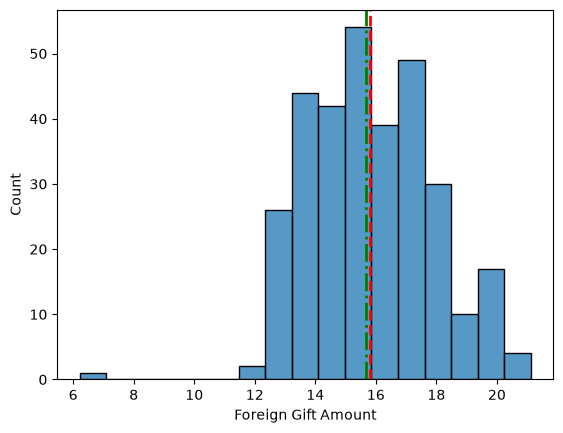

In [85]:
df_amt_log = np.log(df.groupby("Institution Name")['Foreign Gift Amount'].sum().sort_values(ascending=False))
sns.histplot(df_amt_log)
mean_val = df_amt_log.mean()
median_val = df_amt_log.median()
plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='dashdot', linewidth=2, label=f'Median: {median_val:.2f}')

We can now find the z-score of our log-transformed uva gift amount and find other institutions within a tolerance window of that z-score (+/- 0.1 standard deviations) to find universities earning similar gift amounts for us to compare UVA to.

In [ ]:
uva_log = np.log(df_uva['Foreign Gift Amount'].sum())
mean_log = df_amt_log.mean()
std_log = df_amt_log.std()
uva_zscore = (uva_log - mean_log) / std_log

z_tolerance = 0.1
lower_z = uva_zscore - z_tolerance
upper_z = uva_zscore + z_tolerance

log_lower_bound = mean_log + (lower_z * std_log)
log_upper_bound = mean_log + (upper_z * std_log)

df_zwindow = df_amt_log[(df_amt_log >= log_lower_bound) & (df_amt_log <= log_upper_bound)]
df_zwindow

Institution Name
Oregon State University                       17.087
Mayo Clinic College of Medicine and Science   17.076
University of Oklahoma                        17.063
Franklin University                           17.061
University of Kentucky                        17.033
Rensselaer Polytechnic Institute              17.031
University of Florida                         17.025
Colorado State University                     16.993
Washington State University                   16.993
North Carolina State University               16.984
University of Alabama                         16.978
California State University, East Bay         16.964
University of Wisconsin - Madison             16.949
University of Virginia                        16.915
Drexel University                             16.899
University of Illinois at Chicago             16.866
Chapman University                            16.858
Teachers College, Columbia University         16.851
Johnson & Wales University   

In [87]:
similar_univ = df_zwindow.index.tolist()
similar_univ.remove('University of Virginia') # since we only want other institutions
similar_univ

['Oregon State University',
 'Mayo Clinic College of Medicine and Science',
 'University of Oklahoma',
 'Franklin University',
 'University of Kentucky',
 'Rensselaer Polytechnic Institute',
 'University of Florida',
 'Colorado State University',
 'Washington State University',
 'North Carolina State University',
 'University of Alabama',
 'California State University, East Bay',
 'University of Wisconsin - Madison',
 'Drexel University',
 'University of Illinois at Chicago',
 'Chapman University',
 'Teachers College, Columbia University',
 'Johnson & Wales University',
 'Wellesley College',
 'Missouri State University',
 'University of Miami',
 'West Virginia University']

Now using this list of universities we can filter our overall market data by these universities in order to find top giftors/countries for these similar institutions.

In [89]:
df_similar = df[df['Institution Name'].isin(similar_univ)]

df_similar.groupby('Country of Giftor')['Foreign Gift Amount'].sum().nlargest(20)

Country of Giftor
SAUDI ARABIA            98499061
ENGLAND                 57843571
CHINA                   57841164
JAPAN                   35043252
CANADA                  34978222
KUWAIT                  26081776
GERMANY                 21606701
DENMARK                 20625374
OMAN                    19529400
SWITZERLAND             13510747
BAHAMAS                 11158188
UNITED ARAB EMIRATES     7998023
BRAZIL                   7686523
SWEDEN                   6895571
MEXICO                   6515418
AUSTRALIA                6363992
IRELAND                  6144708
SINGAPORE                5129986
THE NETHERLANDS          4471778
SWAZILAND                4105979
Name: Foreign Gift Amount, dtype: int64

In [91]:
df_similar.groupby(['Country of Giftor','Giftor Name'])['Foreign Gift Amount'].sum().nlargest(20)

Country of Giftor  Giftor Name                      
SAUDI ARABIA       Saudi Arabian Cultural Mission       39063512
DENMARK            Novo Nordisk Foundatoin              19194606
SAUDI ARABIA       Saudi Electronic University          13079995
BAHAMAS            Templeton Religion Trust             11158188
ENGLAND            Donor 4                              10471000
GERMANY            Anonymous                            10000000
OMAN               Embassy of the Sultanate of Oman      9972720
KUWAIT             Kuwait-Embassy Of The State           9462320
ENGLAND            Welcome Trust                         8383669
CHINA              Ningxia University                    7412712
SAUDI ARABIA       Saudi Arabia Cultural Mission         6837740
KUWAIT             Embassy of the State of Kuwait        6758075
CANADA             The MasterCard Foundation             6682990
                   Sumagen Canada, Inc.                  6233539
CHINA              IMEC              

We can clearly see that countries like Saudi Arabia, Denmark, Canada and China are some of the top countries gifting to institutions similar to UVA (similar total gift amounts).